# Figure 2: Baseline Comparison (Max vs Sum)

**Paper Figure 2** --- Comparing the two persistence image baselines across a coupling sweep.

- **Max baseline** (conservative): `baseline = max(PI_x, PI_y)` pointwise. Only counts joint topology exceeding the *stronger* marginal at each pixel.
- **Sum baseline** (sensitive): `baseline = PI_x + PI_y`. Counts joint topology exceeding the *combined* marginal mass.

The max baseline should have lower false positive rate at coupling=0. The sum baseline should be more sensitive to weak coupling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.synthetic import coupled_lorenz
from att.binding import BindingDetector

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

In [2]:
set_seed(42)

coupling_values = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
n_steps = 8000
transient = 1000
subsample = 500

scores_max = []
scores_sum = []

for c in coupling_values:
    print(f"coupling={c:.2f} ... ", end="", flush=True)
    ts_x, ts_y = coupled_lorenz(n_steps=n_steps, coupling=c, seed=42)
    X = ts_x[transient:, 0]
    Y = ts_y[transient:, 0]
    
    # Max baseline
    det_max = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
    det_max.fit(X, Y, subsample=subsample, seed=42)
    s_max = det_max.binding_score()
    
    # Sum baseline
    det_sum = BindingDetector(max_dim=1, baseline="sum", embedding_quality_gate=False)
    det_sum.fit(X, Y, subsample=subsample, seed=42)
    s_sum = det_sum.binding_score()
    
    scores_max.append(s_max)
    scores_sum.append(s_sum)
    print(f"max={s_max:.2f}, sum={s_sum:.2f}")

scores_max = np.array(scores_max)
scores_sum = np.array(scores_sum)

coupling=0.00 ... 

max=184.19, sum=182.03
coupling=0.05 ... 

max=252.93, sum=248.71
coupling=0.10 ... 

max=257.21, sum=255.25
coupling=0.20 ... 

max=219.28, sum=214.48
coupling=0.30 ... 

...

max=246.21, sum=238.21
coupling=0.50 ... 

max=191.40, sum=189.74
coupling=0.60 ... 

max=240.52, sum=235.52
coupling=0.80 ... 

max=170.17, sum=164.33
coupling=1.00 ... 

max=89.31, sum=86.95


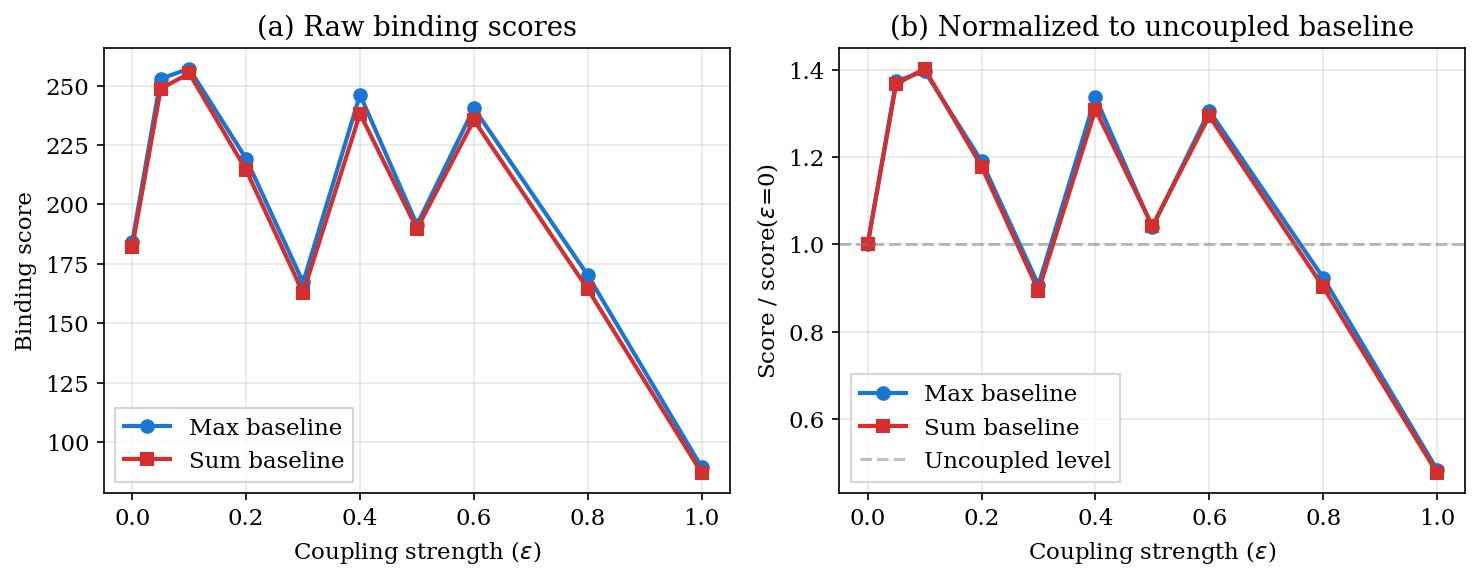

Saved to figures/fig2_baseline_comparison.{pdf,png}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: raw scores
ax = axes[0]
ax.plot(coupling_values, scores_max, 'o-', color='#1976D2', linewidth=2, markersize=6, label='Max baseline')
ax.plot(coupling_values, scores_sum, 's-', color='#D32F2F', linewidth=2, markersize=6, label='Sum baseline')
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Binding score')
ax.set_title('(a) Raw binding scores')
ax.legend(frameon=True, fancybox=False)
ax.grid(True, alpha=0.3)

# Right: normalized (divide by score at c=0 to show relative increase)
ax = axes[1]
norm_max = scores_max / max(scores_max[0], 1e-10)
norm_sum = scores_sum / max(scores_sum[0], 1e-10)
ax.plot(coupling_values, norm_max, 'o-', color='#1976D2', linewidth=2, markersize=6, label='Max baseline')
ax.plot(coupling_values, norm_sum, 's-', color='#D32F2F', linewidth=2, markersize=6, label='Sum baseline')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Uncoupled level')
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Score / score($\\epsilon$=0)')
ax.set_title('(b) Normalized to uncoupled baseline')
ax.legend(frameon=True, fancybox=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../figures/fig2_baseline_comparison.pdf', bbox_inches='tight')
fig.savefig('../figures/fig2_baseline_comparison.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig2_baseline_comparison.{pdf,png}")